In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
base = Path.cwd()
candidates = [base, base.parent, Path("/mnt/data")]
def locate(name):
    for p in candidates:
        q = p / name
        if q.exists():
            return q
    raise FileNotFoundError(name)
details = pd.read_csv(locate("order_details(3).csv"))
timestamps = pd.read_csv(locate("order_timestamp(3).csv"))
for c in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[c] = pd.to_datetime(timestamps[c], errors="coerce")
details["created_date"] = pd.to_datetime(details["created_date"], errors="coerce")
df = details.merge(timestamps, on="order_id", how="inner", validate="one_to_one")
df["BART_raw_min"] = (df["arrived_pickup_at"] - df["start_time_slot"]).dt.total_seconds()/60
df["BART_min"] = df["BART_raw_min"].clip(lower=0)
df["Acceptance_raw_min"] = (df["accept_time"] - df["start_time_slot"]).dt.total_seconds()/60
df["Acceptance_min"] = df["Acceptance_raw_min"].clip(lower=0)
df["Arrival_raw_min"] = (df["arrived_pickup_at"] - df["accept_time"]).dt.total_seconds()/60
df["Arrival_min"] = df["Arrival_raw_min"].clip(lower=0)
df["BART15"] = np.where(df["BART_min"].notna(), (df["BART_min"] <= 15).astype(int), np.nan)
df["hour"] = df["start_time_slot"].dt.hour
df["weekday"] = df["start_time_slot"].dt.day_name()
df["month"] = df["start_time_slot"].dt.month_name()
df["month_num"] = df["start_time_slot"].dt.month
df["date"] = df["start_time_slot"].dt.date
df["hour_bucket"] = df["start_time_slot"].dt.floor("h")
df["distance_km"] = df["total_distance"]/1000
df["fare_m"] = df["order_fare"]/1_000_000
df["fare_per_km"] = np.where(df["distance_km"]>0, df["order_fare"]/df["distance_km"], np.nan)
df["delayed_flag"] = np.where(df["order_offer_badge"].notna(), (df["order_offer_badge"].astype(str).str.lower()=="delayed").astype(int), np.nan)
df["district_str"] = df["district"].astype("Int64").astype(str)
df["city_district"] = df["order_city"].astype(str)+"-"+df["district_str"]
main = df[(df["start_time_slot"] >= pd.Timestamp("2025-08-01")) & (df["start_time_slot"] < pd.Timestamp("2025-11-01")) & df["BART_min"].notna()].copy()
seq = main[(main["start_time_slot"] <= main["accept_time"]) & (main["accept_time"] <= main["arrived_pickup_at"])].copy()
fig_dir = Path("assets/figures")
table_dir = Path("assets/tables")
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir/name, dpi=220, bbox_inches="tight")
    plt.show()
def save_table(data, name, decimals=2):
    x = data.copy()
    for c in x.select_dtypes(include=["float", "float64", "float32"]).columns:
        x[c] = x[c].round(decimals)
    display(x)


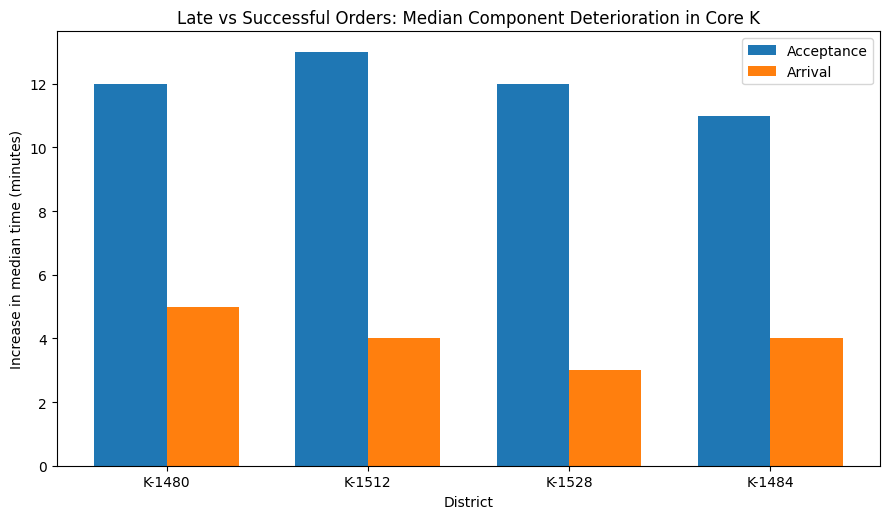

In [2]:
areas=["K-1480","K-1512","K-1528","K-1484"]
rows=[]
for area in areas:
    g=seq[seq["city_district"]==area]
    late=g[g["BART15"]==0]
    good=g[g["BART15"]==1]
    rows.append({"Area":area,"Acceptance_delta":late["Acceptance_min"].median()-good["Acceptance_min"].median(),"Arrival_delta":late["Arrival_min"].median()-good["Arrival_min"].median()})
delta=pd.DataFrame(rows)
x=np.arange(len(delta))
fig, ax = plt.subplots(figsize=(9,5.3))
w=.36
ax.bar(x-w/2,delta["Acceptance_delta"],w,label="Acceptance")
ax.bar(x+w/2,delta["Arrival_delta"],w,label="Arrival")
ax.set_xticks(x,labels=delta["Area"])
ax.set_title("Late vs Successful Orders: Median Component Deterioration in Core K")
ax.set_xlabel("District")
ax.set_ylabel("Increase in median time (minutes)")
ax.legend()
savefig("F11_CoreK_Late_vs_Success_Component_Delta.png")


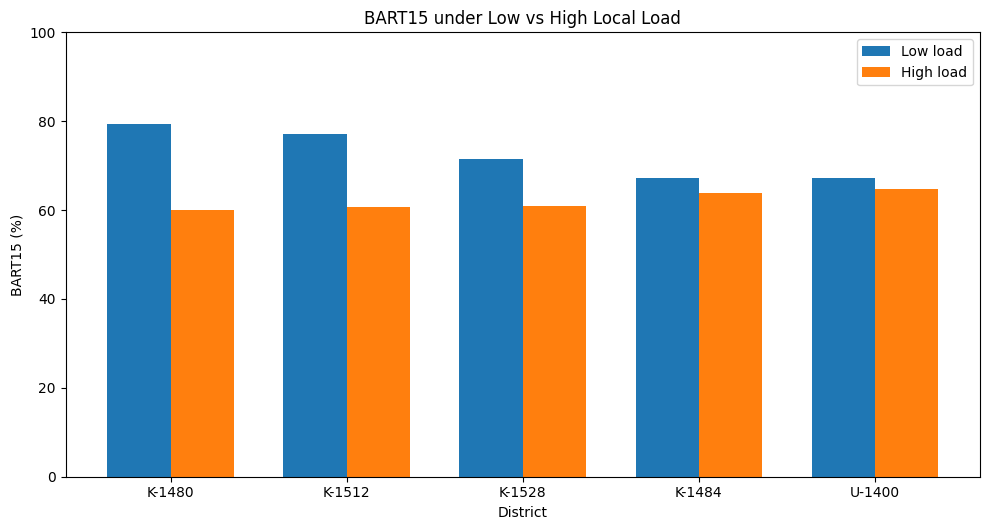

In [3]:
seq15=seq.copy()
seq15["interval15"]=seq15["start_time_slot"].dt.floor("15min")
load=seq15.groupby(["city_district","interval15"]).size().rename("Load").reset_index()
seq15=seq15.merge(load,on=["city_district","interval15"],how="left")
rows=[]
for area in ["K-1480","K-1512","K-1528","K-1484","U-1400"]:
    g=seq15[seq15["city_district"]==area].copy()
    bins=load[load["city_district"]==area]["Load"]
    q1,q3=bins.quantile([.25,.75])
    low=g[g["Load"]<=q1]
    high=g[g["Load"]>=q3]
    rows.append({"Area":area,"Low_load_BART15":low["BART15"].mean()*100,"High_load_BART15":high["BART15"].mean()*100,"Change_pp":(high["BART15"].mean()-low["BART15"].mean())*100})
load_bart=pd.DataFrame(rows)
x=np.arange(len(load_bart))
fig, ax = plt.subplots(figsize=(10,5.4))
w=.36
ax.bar(x-w/2,load_bart["Low_load_BART15"],w,label="Low load")
ax.bar(x+w/2,load_bart["High_load_BART15"],w,label="High load")
ax.set_xticks(x,labels=load_bart["Area"])
ax.set_ylim(0,100)
ax.set_title("BART15 under Low vs High Local Load")
ax.set_xlabel("District")
ax.set_ylabel("BART15 (%)")
ax.legend()
savefig("F12_Load_Sensitivity_BART15.png")


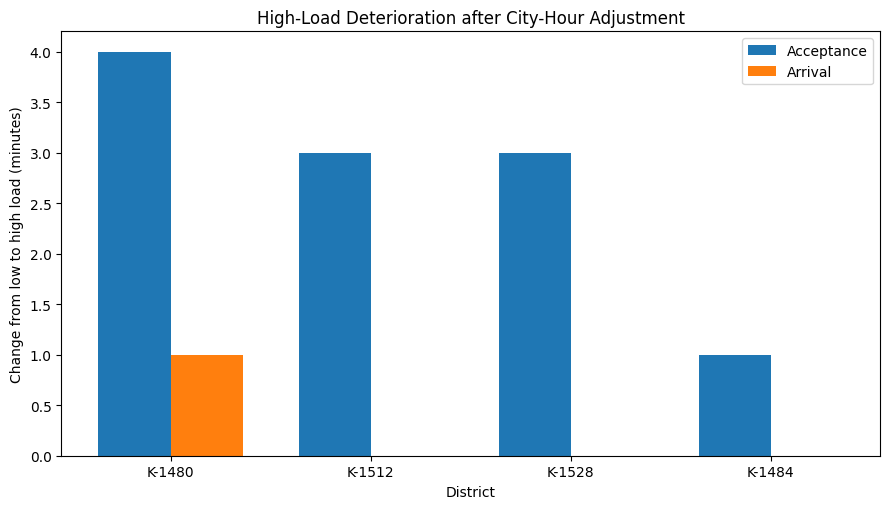

In [4]:
base_a=seq15.groupby(["order_city","hour"])["Acceptance_min"].median().rename("A_base")
base_r=seq15.groupby(["order_city","hour"])["Arrival_min"].median().rename("R_base")
seq15=seq15.join(base_a,on=["order_city","hour"]).join(base_r,on=["order_city","hour"])
seq15["A_dev"]=seq15["Acceptance_min"]-seq15["A_base"]
seq15["R_dev"]=seq15["Arrival_min"]-seq15["R_base"]
rows=[]
for area in ["K-1480","K-1512","K-1528","K-1484"]:
    g=seq15[seq15["city_district"]==area].copy()
    bins=load[load["city_district"]==area]["Load"]
    q1,q3=bins.quantile([.25,.75])
    low=g[g["Load"]<=q1]
    high=g[g["Load"]>=q3]
    rows.append({"Area":area,"Acceptance_change":high["A_dev"].median()-low["A_dev"].median(),"Arrival_change":high["R_dev"].median()-low["R_dev"].median()})
chg=pd.DataFrame(rows)
x=np.arange(len(chg))
fig, ax = plt.subplots(figsize=(9,5.2))
w=.36
ax.bar(x-w/2,chg["Acceptance_change"],w,label="Acceptance")
ax.bar(x+w/2,chg["Arrival_change"],w,label="Arrival")
ax.set_xticks(x,labels=chg["Area"])
ax.set_title("High-Load Deterioration after City-Hour Adjustment")
ax.set_xlabel("District")
ax.set_ylabel("Change from low to high load (minutes)")
ax.legend()
savefig("F13_CoreK_Load_Component_Changes.png")


In [5]:
rows=[]
for area,h in [("K-1480",20),("K-1512",12),("K-1528",12),("K-1528",13)]:
    g=seq[(seq["city_district"]==area)&(seq["hour"]==h)]
    city=area.split("-")[0]
    b=seq[(seq["order_city"]==city)&(seq["hour"]==h)]
    rows.append({"Area-Hour":f"{area} H{h}","Sequential Orders":len(g),"BART15 (%)":g["BART15"].mean()*100,"Acceptance Median Gap":g["Acceptance_min"].median()-b["Acceptance_min"].median(),"Acceptance P90 Gap":g["Acceptance_min"].quantile(.9)-b["Acceptance_min"].quantile(.9),"Arrival P90 Gap":g["Arrival_min"].quantile(.9)-b["Arrival_min"].quantile(.9)})
hot=pd.DataFrame(rows)
save_table(hot,"T05_District_Hour_Hotspots.png")


,Area-Hour,Sequential Orders,BART15 (%),Acceptance Median Gap,Acceptance P90 Gap,Arrival P90 Gap
0,K-1480 H20,2846,56.11,6.0,1.0,-1.0
1,K-1512 H12,1258,48.97,4.0,5.0,-1.0
2,K-1528 H12,790,51.77,4.0,4.0,-2.0
3,K-1528 H13,877,57.24,7.0,4.0,-1.0


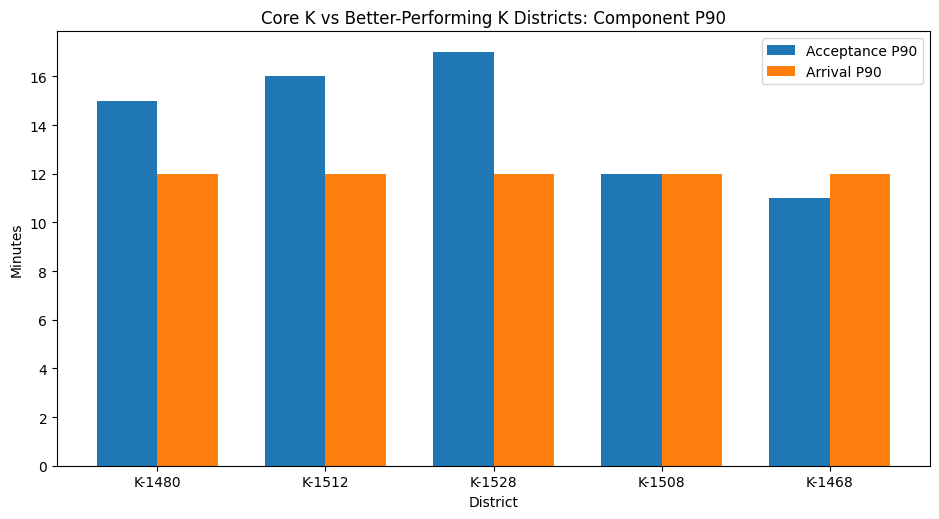

In [6]:
compare=["K-1480","K-1512","K-1528","K-1508","K-1468"]
rows=[]
for area in compare:
    g=seq[seq["city_district"]==area]
    rows.append({"Area":area,"Acceptance P90":g["Acceptance_min"].quantile(.9),"Arrival P90":g["Arrival_min"].quantile(.9)})
p90=pd.DataFrame(rows)
x=np.arange(len(p90))
fig, ax = plt.subplots(figsize=(9.5,5.3))
w=.36
ax.bar(x-w/2,p90["Acceptance P90"],w,label="Acceptance P90")
ax.bar(x+w/2,p90["Arrival P90"],w,label="Arrival P90")
ax.set_xticks(x,labels=p90["Area"])
ax.set_title("Core K vs Better-Performing K Districts: Component P90")
ax.set_xlabel("District")
ax.set_ylabel("Minutes")
ax.legend()
savefig("F14_CoreK_vs_BetterK_Component_P90.png")


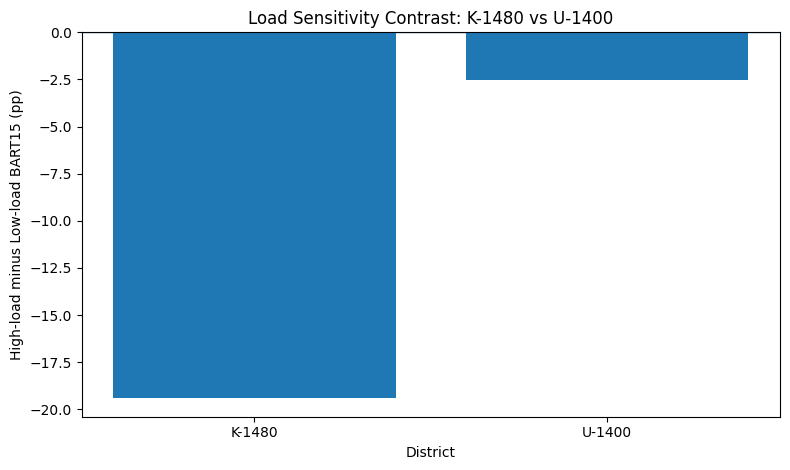

In [7]:
fig, ax = plt.subplots(figsize=(8,4.8))
y=load_bart.set_index("Area").loc[["K-1480","U-1400"],"Change_pp"]
ax.bar(y.index,y.values)
ax.axhline(0,linewidth=1)
ax.set_title("Load Sensitivity Contrast: K-1480 vs U-1400")
ax.set_xlabel("District")
ax.set_ylabel("High-load minus Low-load BART15 (pp)")
savefig("F15_K1480_vs_U1400_Load_Sensitivity.png")


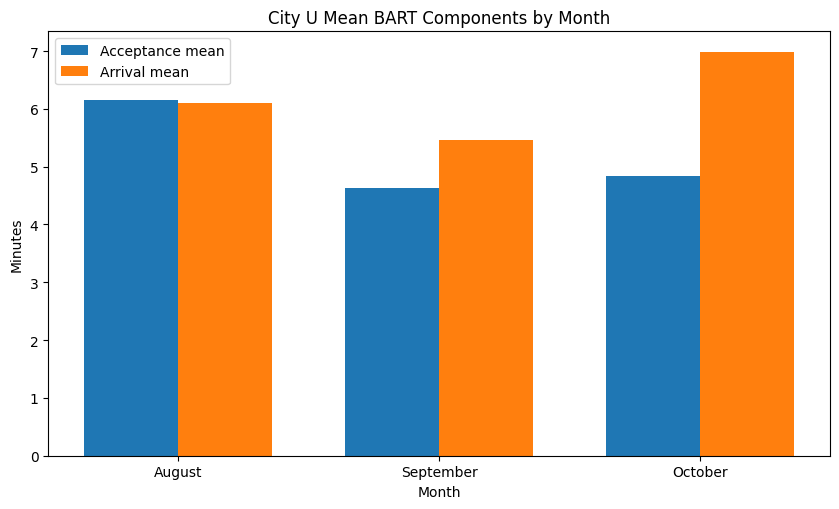

In [8]:
u=seq[seq["order_city"]=="U"].groupby("month_num").agg(Acceptance_Mean=("Acceptance_min","mean"),Arrival_Mean=("Arrival_min","mean"),BART_Mean=("BART_min","mean")).reset_index()
x=np.arange(len(u))
fig, ax = plt.subplots(figsize=(8.5,5.2))
w=.36
ax.bar(x-w/2,u["Acceptance_Mean"],w,label="Acceptance mean")
ax.bar(x+w/2,u["Arrival_Mean"],w,label="Arrival mean")
ax.set_xticks(x,labels=["August","September","October"])
ax.set_title("City U Mean BART Components by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Minutes")
ax.legend()
savefig("F16_CityU_Monthly_Component_Means.png")


In [9]:
selected=["K-1480","K-1512","K-1528","K-1508","U-1400","U-1420","B-3740","B-3720","K-4176","K-4532","K-4732"]
rows=[]
for area in selected:
    gm=main[main["city_district"]==area]
    gs=seq[seq["city_district"]==area]
    rows.append({"Area":area,"Orders":len(gm),"BART15 (%)":gm["BART15"].mean()*100,"Acceptance P90":gs["Acceptance_min"].quantile(.9),"Arrival P90":gs["Arrival_min"].quantile(.9),"Delayed Offer Rate (%)":gm["delayed_flag"].mean()*100})
summary=pd.DataFrame(rows)
save_table(summary,"T06_Selected_Area_Process_Summary.png")


,Area,Orders,BART15 (%),Acceptance P90,Arrival P90,Delayed Offer Rate (%)
0,K-1480,26893,70.19,15.0,12.0,27.76
1,K-1512,10864,69.01,16.0,12.0,26.99
2,K-1528,7115,66.38,17.0,12.0,29.81
3,K-1508,8887,80.77,12.0,12.0,14.28
4,U-1400,4162,69.82,21.0,11.0,24.17
5,U-1420,12031,85.99,12.0,10.0,10.77
6,B-3740,4543,85.16,9.0,16.0,0.00
7,B-3720,9460,92.91,9.0,9.0,0.00
8,K-4176,4216,71.85,12.0,28.0,0.07
9,K-4532,4797,83.24,4.0,24.0,0.00
